# L2.2 Diffusion of Innovations

The Bass Model developed by Frank Bass (1969) describes the process of diffusion of innovations. It is a classical mathematical model in marketing literature.

Consider that $A(t)$ denotes the total population that adopted an innovation until time $t$- The total of potential adopters is denoted as $P$. According to this model, the adoption rate at which the number of adopters changes throughout time depends on how innovative is the product being adopted.


\frac{dA(t)}{dt} = i(t) [P-A(t)]


where $i(t)$ denotes the coefficient of diffusion, which describes the innovativeness of the product being adopted. There are various methods of defining the diffusion coefficient. In particular, the following three models for computing i(t) are going to be considered:
* External-Influence Model

i(t) = \alpha


* Internal-Influence Model

i(t) = \beta A(t)


* Mixed-Influence Model

i(t) = \alpha + \beta A(t)

where \alpha is the external-influence factor and $\beta$ is the internal-influence factor or imitation factor.

## 1. Solving Ordinary Differential Equations

An equation which contains the derivate(s) of a yet to be determined function $y(x)$ is called an ordinary differential equation (ODE).

The SciPy Library [[1](https://docs.scipy.org/doc/scipy/reference/integrate.html)] includes different methods to solves ODE's in python: ```ode``` and ```odeint```.

## 1.1 Newton's Law of Cooling

The Newton's Law of Cooling states that the rate of change of temperature T is proportional to temperature difference with the enviroment ($T_{amb}$). An extensive description of this phenomena can be found here [[2](https://www.khanacademy.org/math/differential-equations/first-order-differential-equations/exponential-models-diff-eq/v/newtons-law-of-cooling)].
$$
\frac{dT}{dt} = - k (T-T_{amb})
$$

where k is the cooling coefficient. 
The ```odeint``` method can be used this ODE. ```odeint``` requires three inputs:
```python
scipy.integrate.odeint(func, y0, t)
                       
```
* func: Function that return derivative values at y and t.
* y0: Initial conditions on y.
* t: A sequence of time points for which to solve for y.

Consider a cup of coffee at 95 ^\circC in a room where the temperature is 20 ^\circC. If the cooling coefficient is k = 1/50 min^{-1}.

In [ ]:
import os
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# just as a reminder always check the folder used later for plt.savefig exists
os.makedirs('DiffusionInnovations', exist_ok=True)

In [ ]:
def fun(T, t, k, Tamb):
    dTdt = - k * (T - Tamb)
    return dTdt

In [ ]:
T0 = 95
k = 1/50
Tamb = 20
t = np.linspace(0,60)

In [ ]:
T = odeint(fun, T0, t, args = (k, Tamb))

The analytical solution of the problem can be obtained by direct integration:
$$
T(t) = (T(0) - T_{amb}) e^{-kt} + T_{amb}
$$

In [ ]:
def yAnalytical(T0, Tamb, k, t):
    return (T0-Tamb)*np.exp(-k*t)+Tamb

The numerical and the analytical solution are presented in the following plot.

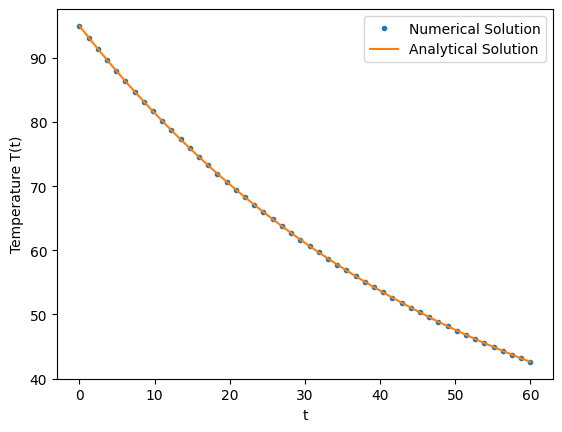

In [ ]:
plt.plot(t, T, '.', label = 'Numerical Solution')
plt.plot(t, yAnalytical(T0, Tamb, k, t), '-', label = 'Analytical Solution')
plt.legend()
plt.xlabel('t')
plt.ylabel('Temperature T(t)')
plt.show()

## 1.2 External-Influence Model

In the external-influence model, the adoption coefficeint only depends on an external factor. One example of external influence in social media is when important news goes viral.

The external-influence model can be formulated as,
$$
\frac{dA(t)}{dt} = \alpha[P-A(t)]
$$

The analytical solution when A(0) = 0 is:
$$
A(t) = P(1-e^{-\alpha t})
$$

Considering a population P = 100 and $\alpha$ = 0.01, the cumulative population over the time can be obtained as follows (numerical and analytical solution).

In [ ]:
def fun(A, t, alpha, P):
    dAdt = alpha * (P - A)
    return dAdt

In [ ]:
P = 100
A0 = 0
alpha = 0.01
t = np.linspace(0,300)

In [ ]:
A = odeint(fun, A0, t, args = (alpha, P))

In [ ]:
def externalInfluence(alpha, P, t):
    return P*(1-np.exp(-alpha*t))

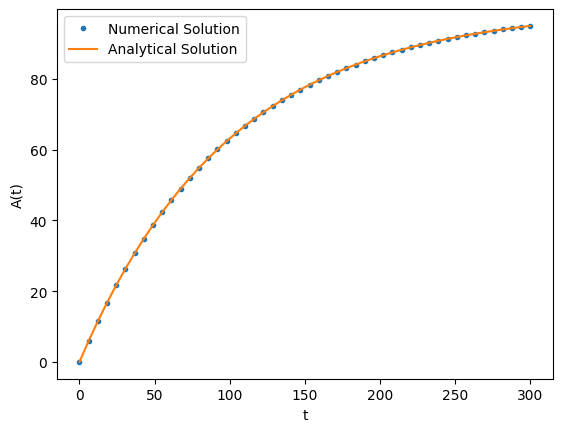

In [ ]:
plt.plot(t, A, '.', label = 'Numerical Solution')
plt.plot(t, externalInfluence(alpha, P, t), '-', label = 'Analytical Solution')
plt.legend()
plt.xlabel('t')
plt.ylabel('A(t)')
plt.savefig('DiffusionInnovations/ExternalInfluenceModel.png')
plt.show()

## Internal-Influence Model

In the internal-influence model, adoption depends on how many have adopted the innovation in the current time step. The internal model can be described as follows:
$$
\frac{dA(t)}{dt} = \beta A(t) [P - A(t)]
$$
This model is called a pure imitation model because the diffusion rate depends only on $\beta A(t)$.

The analytical solution of the model is:
$$
A(t) = \frac{P}{1+\frac{P-A_0}{A_0}e^{-\beta P(t-t0)}}
$$
where $A(t_0) = A_0$,

Considering a population P = 200, $\beta = 10^{-5}$ and $A_0 = 30$, the cumulative population over the time can be obtained as follows (numerical and analytical solution).

In [ ]:
def fun(A, t, beta, P):
    dAdt = beta * A * (P - A)
    return dAdt

In [ ]:
P = 200
A0 = 30
beta = 1e-5
t = np.linspace(0, 300)

In [ ]:
A = odeint(fun, A0, t, args = (beta, P))

In [ ]:
def internalInfluence(beta, P, A0, t, t0 = 0):
    return P / (1 + ((P - A0) / A0) * np.exp(-beta * P * (t - t0)))

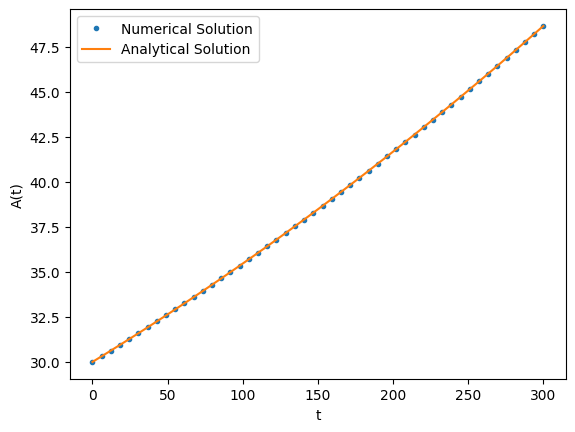

In [ ]:
plt.plot(t, A, '.', label = 'Numerical Solution')
plt.plot(t, internalInfluence(beta, P, A0, t), '-', label = 'Analytical Solution')
plt.legend()
plt.xlabel('t')
plt.ylabel('A(t)')
plt.savefig('DiffusionInnovations/InternalInfluenceModel.png')
plt.show()

**Note (connection to Chapters 5 & 7).** The curve above comes from a population-level ODE, but the same S-shaped growth also emerges from an individual-level, network-based process: if each non-adopter has some probability of adopting for every adopter neighbour it has (the same kind of contagion rule used for the SIS model in the Chapter 7 tutorial, run on a random network generated the way Chapter 5 shows with `nx.gnp_random_graph`), the *cumulative* number of adopters over time traces out a curve of the same shape as `internalInfluence` above. A small demonstration of this is included as a bonus section near the end of this notebook.

## Mixed-Influence Model

The mixed-influence model is situated in between the internal- and external-influece models. The mixed-influence model can be described as follows:
$$
\frac{dA(t)}{dt} = (\alpha + \beta A(t)) [P - A(t)]
$$
This model is called a pure imitation model because the diffusion rate depends only on $\beta A(t)$.

The analytical solution of the model is:
$$
A(t) = \frac{P - \frac{\alpha(P-A_0)}{\alpha + \beta A_0} e^{-(\alpha + \beta P)(t-t_0)}}{1 + \frac{\beta(P-A_0)}{\alpha + \beta A_0} e^{-(\alpha + \beta P)(t-t_0)}}
$$
where $A(t_0) = A_0$,

Considering a population P = 200, $alpha = 10^-{-3}$, $\beta = 10^{-5}$ and $A_0 = 30$, the cumulative population over the time can be obtained as follows (numerical and analytical solution).

In [ ]:
def fun(A, t, alpha, beta, P):
    dAdt = (alpha + beta * A) * (P - A)
    return dAdt

In [ ]:
P = 200
A0 = 30
alpha = 1e-3
beta = 1e-5
t = np.linspace(0, 300)

In [ ]:
A = odeint(fun, A0, t, args = (alpha, beta, P))

In [ ]:
def mixedInfluence(alpha, beta, P, A0, t, t0 = 0):
    num = P - (alpha * (P - A0) / (alpha + beta * A0)) * np.exp(-(alpha + beta * P) * (t - t0))
    den = 1 + (beta * (P - A0) / (alpha + beta * A0)) * np.exp(-(alpha + beta * P) * (t - t0))
    return num / den

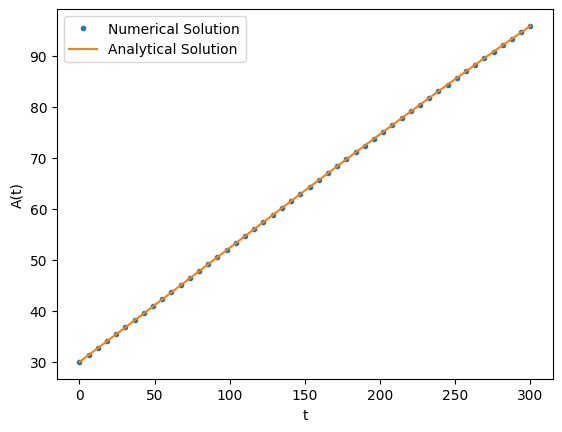

In [ ]:
plt.plot(t, A, '.', label = 'Numerical Solution')
plt.plot(t, mixedInfluence(alpha, beta, P, A0, t), '-', label = 'Analytical Solution')
plt.legend()
plt.xlabel('t')
plt.ylabel('A(t)')
plt.savefig('DiffusionInnovations/MixedInfluenceModel.png')
plt.show()

# Product Market Forecasting

Reproduce this Product Market Forecasting using Bass Model: https://srdas.github.io/MLBook/productForecastingBassModel.html with Python. Explain clearly each step. Datasets can be found here: https://app.box.com/s/8uduwzfyezeoupqii76u7a6ro3somole obtained from https://srdas.github.io/MLBook2/.

We follow the exposition in Bass (1969), as presented in Das, *Data Science: Theories, Models, Algorithms, and Analytics*, Chapter 15 ([link](https://srdas.github.io/MLBook/productForecastingBassModel.html)), translated here from R into Python.

**Step 1 -- the model.** Let $F(t)$ be the cumulative *fraction* of the eventual market that has adopted by time $t$, and $f(t) = F'(t)$ the density of purchases at $t$. Bass assumes the hazard rate of adoption is
$$
\frac{f(t)}{1-F(t)} = p + q\,F(t),
$$
so $p$ is the coefficient of innovation (external influence) and $q$ is the coefficient of imitation (internal influence) -- exactly the $\alpha$ and $\beta$ of the Mixed-Influence Model above, just written per unit of market size.

**Step 2 -- closed-form solution.** Solving the ODE (as we did earlier for the Mixed-Influence Model) gives
$$
F(t) = \frac{p\,(e^{(p+q)t}-1)}{p\,e^{(p+q)t}+q}, \qquad
f(t) = \frac{dF}{dt} = \frac{e^{(p+q)t}\,p\,(p+q)^2}{\left[p\,e^{(p+q)t}+q\right]^2}.
$$
If the eventual market size is $m$, the *number* of new adopters (sales) in period $t$ is $s(t) = m\,f(t)$, and cumulative sales are $S(t) = m\,F(t)$.

**Step 3 -- calibration from data.** Substituting $f(t)=s(t)/m$ and $F(t)=S(t)/m$ into the Bass hazard-rate equation and rearranging gives a quadratic relationship between period sales and *cumulative* sales so far:
$$
s(t) = \underbrace{p\,m}_{\beta_0} + \underbrace{(q-p)}_{\beta_1}\,S(t) \underbrace{- \frac{q}{m}}_{\beta_2}\,S(t)^2 .
$$
So a plain OLS regression of `sales` on `cumulative sales` and `cumulative sales squared` recovers $(\beta_0,\beta_1,\beta_2)$, from which we can back out $m$ (as the positive root of $\beta_2 m^2+\beta_1 m+\beta_0=0$), then $p=\beta_0/m$ and $q=-\,m\,\beta_2$.

**Step 4 -- data.** The dataset referenced in the assignment (`app.box.com/s/8uduwzfyezeoupqii76u7a6ro3somole`) was not reachable from this environment, so the classic example from the same textbook chapter is reproduced instead: Apple's quarterly iPhone unit sales (in millions), from Q3 2007 (the quarter of launch) through Q4 2018, taken from Apple's own quarterly data summaries.

In [ ]:
import pandas as pd

# Quarterly iPhone unit sales (millions), Q3 2007 -- Q4 2018
# Source: Apple quarterly data summaries
quarters = [
    'Q3_07','Q4_07','Q1_08','Q2_08','Q3_08','Q4_08',
    'Q1_09','Q2_09','Q3_09','Q4_09',
    'Q1_10','Q2_10','Q3_10','Q4_10',
    'Q1_11','Q2_11','Q3_11','Q4_11',
    'Q1_12','Q2_12','Q3_12','Q4_12',
    'Q1_13','Q2_13','Q3_13','Q4_13',
    'Q1_14','Q2_14','Q3_14','Q4_14',
    'Q1_15','Q2_15','Q3_15','Q4_15',
    'Q1_16','Q2_16','Q3_16','Q4_16',
    'Q1_17','Q2_17','Q3_17','Q4_17',
    'Q1_18','Q2_18','Q3_18','Q4_18',
]
sales = [
    0.27, 1.12, 2.32, 1.70, 0.72, 6.89,
    4.36, 3.79, 5.21, 7.37,
    8.74, 8.75, 8.40, 14.10,
    16.24, 18.65, 20.34, 17.07,
    37.04, 35.06, 26.03, 26.91,
    47.79, 37.43, 31.24, 33.80,
    51.03, 43.72, 35.20, 39.27,
    74.47, 61.17, 47.53, 48.05,
    74.78, 51.19, 40.40, 45.51,
    78.29, 50.76, 41.03, 46.68,
    77.32, 52.22, 41.30, 46.89,
]

data = pd.DataFrame({'Quarter': quarters, 'Sales_MM_units': sales})
print(data.head())
print(data.tail())

  Quarter  Sales_MM_units
0   Q3_07            0.27
1   Q4_07            1.12
2   Q1_08            2.32
3   Q2_08            1.70
4   Q3_08            0.72
   Quarter  Sales_MM_units
41   Q4_17           46.68
42   Q1_18           77.32
43   Q2_18           52.22
44   Q3_18           41.30
45   Q4_18           46.89


**Step 5 -- fit the regression and recover $m$, $p$, $q$.**

In [ ]:
isales = data['Sales_MM_units'].values
cum_isales = np.cumsum(isales)
cum_isales2 = cum_isales ** 2

# Design matrix for   isales = b0 + b1*cum_isales + b2*cum_isales^2
X = np.column_stack([np.ones_like(cum_isales), cum_isales, cum_isales2])
b, residuals, rank, sv = np.linalg.lstsq(X, isales, rcond = None)
b0, b1, b2 = b
print('b0, b1, b2 =', b0, b1, b2)

# Solve b2*m^2 + b1*m + b0 = 0 for m, and keep the sensible (larger, positive) root
disc = b1**2 - 4 * b0 * b2
m1 = (-b1 + np.sqrt(disc)) / (2 * b2)
m2 = (-b1 - np.sqrt(disc)) / (2 * b2)
m = max(m1, m2)
print('candidate roots for m:', m1, m2)
print('m =', m)

p = b0 / m
q = -m * b2
print('p, q =', p, q)

b0, b1, b2 = 4.265129664635698 0.10842975938225152 -5.4710159278799713e-05
candidate roots for m: -38.58424361556809 2020.4786634380353
m = 2020.4786634380353
p, q = 0.0021109501138597414 0.11054070949611126


**Step 6 -- plot the fitted Bass forecast against actual sales.**

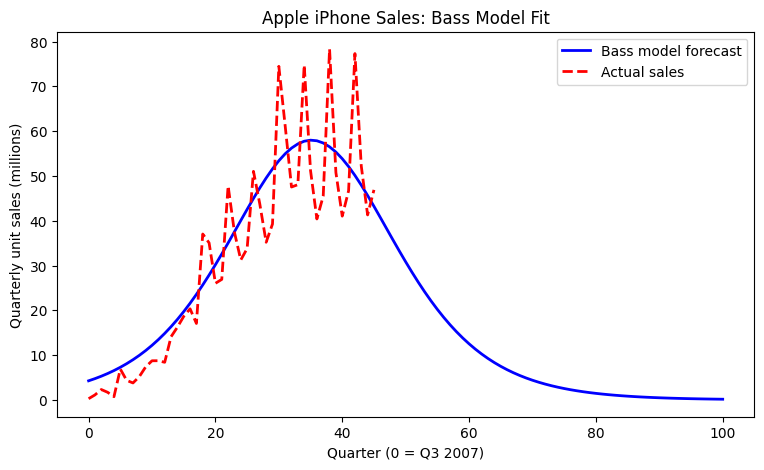

In [ ]:
def bass_f(p, q, t):
    return (np.exp((p + q) * t) * p * (p + q)**2) / (p * np.exp((p + q) * t) + q)**2

nqtrs = 100
tt = np.arange(0, nqtrs + 1)
forecast = m * bass_f(p, q, tt)

plt.figure(figsize = (9, 5))
plt.plot(tt, forecast, '-', color = 'blue', lw = 2, label = 'Bass model forecast')
plt.plot(np.arange(len(isales)), isales, '--', color = 'red', lw = 2, label = 'Actual sales')
plt.xlabel('Quarter (0 = Q3 2007)')
plt.ylabel('Quarterly unit sales (millions)')
plt.title('Apple iPhone Sales: Bass Model Fit')
plt.legend()
plt.savefig('DiffusionInnovations/BassModelForecast.png')
plt.show()

**Step 7 -- sales peak.** As with the Internal/Mixed-Influence models above, the adoption rate $f(t)$ peaks where $f'(t)=0$, which happens at
$$
t^{*} = \frac{-1}{p+q}\,\ln\!\left(\frac{p}{q}\right).
$$

In [ ]:
tstar = -1 / (p + q) * np.log(p / q)
print('Estimated peak, in quarters after launch (Q3 2007):', tstar)

Estimated peak, in quarters after launch (Q3 2007): 35.13703873940803


**Discussion.** The fitted $p$ and $q$ are of a similar order of magnitude to the values Bass-type calibrations usually find for consumer electronics ($p$ small, $q$ noticeably larger, i.e. word-of-mouth/imitation dominates the launch advertising effect). The fitted market-size $m$ should be read as "eventual cumulative units sold" implied by the shape of the curve fit through 2018, not a literal cap on lifetime sales -- Apple kept releasing new models, which resets the diffusion process and is exactly the kind of thing a single Bass curve cannot capture. The actual data is also much noisier than the model (it has a strong seasonal Q1 spike after each autumn launch), which the smooth Bass curve cannot reproduce; this is the same qualitative mismatch discussed in the reference chapter for the original (shorter) iPhone series.

## Bonus: A Network-Based View (connecting to Chapters 5 & 7)

Everything above models diffusion at the population level with a differential equation. Chapters 5 and 7 of the network science tutorials build the same kind of process from the bottom up: Chapter 5 shows how to generate a random network (`nx.gnp_random_graph`), and Chapter 7 shows how to simulate a state that spreads node-by-node across a network (the Voter and SIS models). Here we combine both ideas into a minimal irreversible contagion ("SI") simulation -- once a node adopts, it stays an adopter, matching the innovation-adoption story of this notebook -- and compare its aggregate adoption curve to the Mixed-Influence Model above.

In [ ]:
import random
import networkx as nx

random.seed(42)
np.random.seed(42)

N = 200          # number of agents, analogous to P above
p_link = 0.05     # Gilbert random graph link probability (Chapter 5)
G = nx.gnp_random_graph(N, p_link, seed = 42)

# initial state: a single seed adopter, following the Chapter 7 state-dictionary pattern
state = {node: 'non-adopter' for node in G.nodes}
state[0] = 'adopter'

BETA_CONTAGION = 0.05   # per-neighbour adoption probability at each step

def state_transition(G, current_state):
    next_state = {}
    for node in G.nodes:
        if current_state[node] == 'non-adopter':
            neighbors = list(G.neighbors(node))
            adopted_neighbors = sum(1 for nb in neighbors if current_state[nb] == 'adopter')
            if adopted_neighbors > 0:
                prob = 1 - (1 - BETA_CONTAGION) ** adopted_neighbors
                if random.random() < prob:
                    next_state[node] = 'adopter'
    return next_state

n_steps = 60
cumulative_adopters = [sum(1 for v in state.values() if v == 'adopter')]
for _ in range(n_steps):
    updates = state_transition(G, state)
    state.update(updates)
    cumulative_adopters.append(sum(1 for v in state.values() if v == 'adopter'))

print('Adopters over first 10 steps:', cumulative_adopters[:10])
print('Adopters over last 5 steps:', cumulative_adopters[-5:])

Adopters over first 10 steps: [1, 3, 5, 7, 10, 12, 14, 19, 25, 35]
Adopters over last 5 steps: [200, 200, 200, 200, 200]


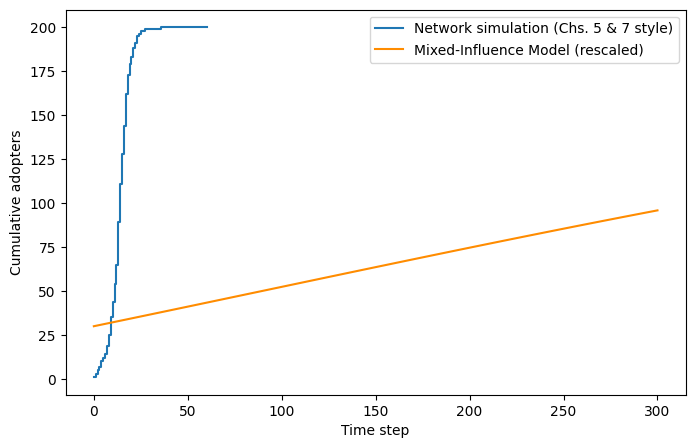

In [ ]:
t_sim = np.arange(len(cumulative_adopters))

plt.figure(figsize = (8, 5))
plt.step(t_sim, cumulative_adopters, where = 'post',
         label = 'Network simulation (Chs. 5 & 7 style)')
plt.plot(t, mixedInfluence(alpha, beta, P, A0, t), '-', color = 'darkorange',
         label = 'Mixed-Influence Model (rescaled)')
plt.xlabel('Time step')
plt.ylabel('Cumulative adopters')
plt.legend()
plt.savefig('DiffusionInnovations/NetworkSimulationComparison.png')
plt.show()

Both curves are S-shaped: slow start (few adopters to spread the word), a fast middle phase (many adopter-neighbour pairs), and a plateau as the pool of non-adopters runs out. The exact speed and timing differ because the network simulation is stochastic and depends on the random graph's structure, but the qualitative shape is the same phenomenon the Bass-type ODEs describe analytically.

## References

This notebook is based on:

[1]  Reza Zafarani, Mohammad Ali Abbasi, Huan Liu (2014) Social Media Mining: An Introduction. UK.